# Modal Analysis on MDOF System

## Introduction

This Jupyter Notebook provides a structured workflow for performing a modal analysis on a calibrated multi-degree-of-freedom (MDOF) stick model based on SDOF capacity. 

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDOF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration) based on the displacement-based design methodology of Priestley et al. [1] and other modifications [2] to account for distinct response typologies (i.e., bilinear, trilinear and quadrilinear backbone definitions)

2. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including mass, heights, fundamental period and nonlinear response characteristics at each degree of freedom

3. **Run Modal Analysis in OpenSees**: Compute the eigenvalues and eigenvectors of the MDOF stick model to obtain its dynamic characteristics, including natural frequencies, periods, and mode shapes. These modal properties provide insight into the structure’s dynamic behavior and can be used to derive modal participation factors, effective modal masses, and other key parameters for subsequent dynamic analyses (e.g., response spectrum or time-history analysis).

The notebook provides a step-by-step guide, covering each phase from MDOF model calibration, setup to input parameter configuration, analysis execution, and detailed results extraction and postprocessing. Users should have some familiarity with python scripts, structural dynamics, computational modeling, and performance-based earthquake engineering to fully benefit from this material.

## References

[1] Priestley, M., Calvi, G. and Kowalski, M. (2007) Displacement-based seismic design of structures. IUSS Press, Pavia.

[2] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. Earthquake Spectra. 2020;36(2):806-831. doi:10.1177/8755293019891724

## Initialize Libraries ##

In [1]:
import numpy as np

# Import the classes necessary for structural analysis
from openquake.vmtk.calibration   import calibrate_model    # OQ-VMTK sdof-to-mdof calibration class
from openquake.vmtk.modeller      import modeller           # OQ-VMTK numerical modelling class
from openquake.vmtk.plotter       import plotter            # OQ-VMTK plotting class
from openquake.vmtk.units         import units              # OQ-VMTK units class

## Calibrate an MDOF Model based on SDOF Capacity ##

In [5]:
# Number of storeys
number_storeys = 9

# Relative floor heights list
storey_heights = [2.80]*number_storeys

# SDOF capacity with a trilinear backbone
sdof_capacity = np.array([[0.009891, 0.079128, 0.2142],      # spectral displacements [in m]
                          [0.2356000, 0.4712500, 0.47596]]).T   # spectral accelerations [in g]

# Soft-storey mechanism flag
isSOS = False

# Degradation flag 
mdof_degradation = False

# Inherent damping 
mdof_damping = 0.05

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(number_storeys,
                                                                             sdof_capacity,
                                                                             isSOS=isSOS,
                                                                             storey_heights=storey_heights,
                                                                             verbose=False)

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2004 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2005 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2006 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2007 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2008 has L= 2.8, which is greater than the tolerance


## Compile MDOF Stick Model and Run Modal Analysis ##

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2004 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2005 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2006 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2007 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2008 has L= 2.8, which is greater than the tolerance


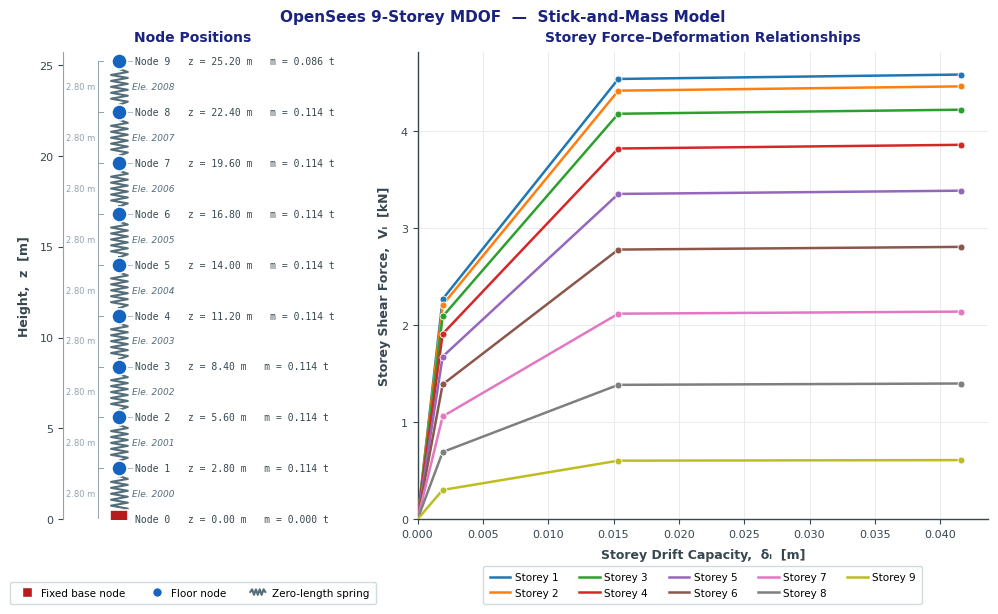

# MODAL ANALYSIS REPORT

* 1. DOMAIN SIZE:
# This is the size of the problem: 1 for 1D problems, 2 for 2D problems, 3 for 3D problems.
3


* 2. EIGENVALUE ANALYSIS:
#          MODE        LAMBDA         OMEGA     FREQUENCY        PERIOD
# ------------- ------------- ------------- ------------- -------------
              1       233.671       15.2863       2.43289      0.411034
              2       233.671       15.2863       2.43289      0.411034
              3       1283.25       35.8225       5.70133      0.175398
              4       1283.25       35.8225       5.70133      0.175398
              5       3024.69       54.9972       8.75307      0.114246
              6       3024.69       54.9972       8.75307      0.114246
              7       5581.83       74.7117       11.8907     0.0840991
              8       5581.83       74.7117       11.8907     0.0840991


* 3. TOTAL MASS OF THE STRUCTURE:
# The total masses (translational and rotational) of the structure
# including 

Fundamental Period: T = 0.411 s


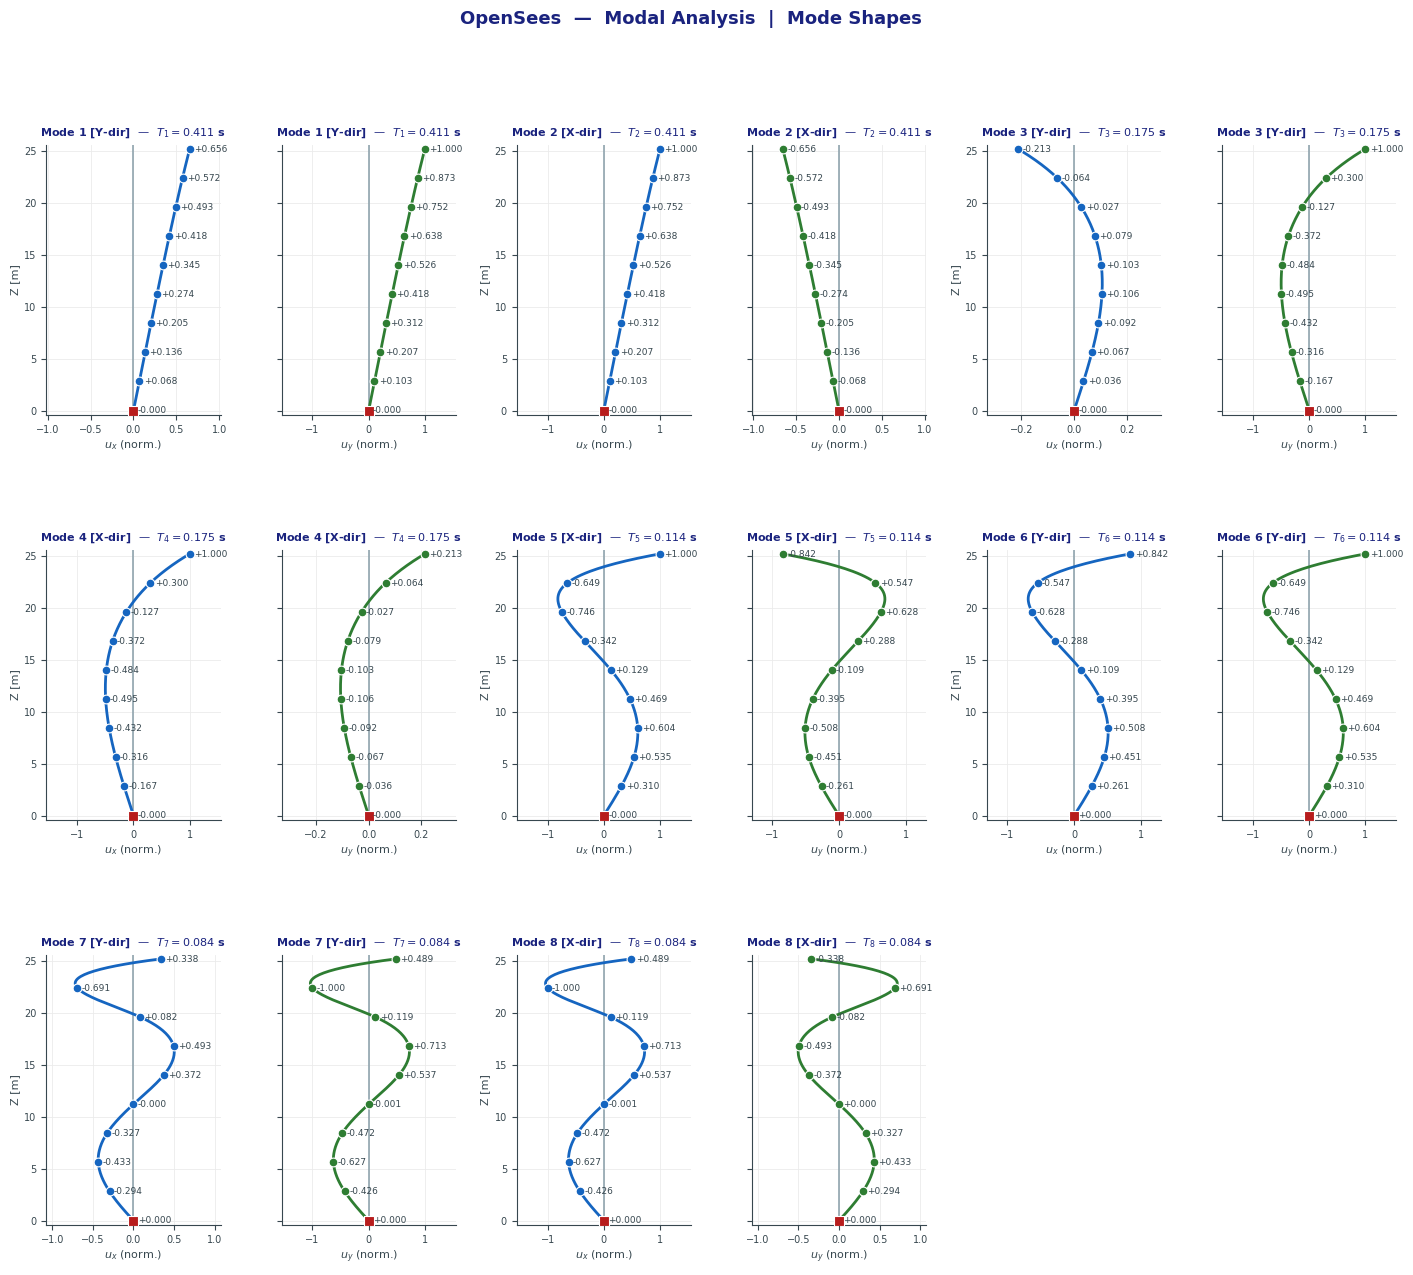

In [7]:
# Initialise the modeller class and compile the MDOF model 
model = modeller(number_storeys, 
                 storey_heights, 
                 floor_masses,
                 storey_drifts, 
                 storey_forces*units.g, 
                 mdof_degradation)
model.compile_model()

# Visualise the stick model
model.plot_model(pFlag = True,
                 export_path = './out/mdof_model.png')   

# Do gravity analysis for system equilibrium
model.do_gravity_analysis()

# Do modal analysis
num_modes = 8
T, phi = model.do_modal_analysis(num_modes=num_modes,                       # Get N-modes
                                 pFlag = True,                              # Prints modal analysis report
                                 plot_modes=True,                           # Plots modal analysis results 
                                 export_path = 'out/modal_analysis.png')    # Exports modal analysis results  